# VQE Ansatz Analysis
### Expressibility & Trainability

Este notebook evalúa los 19 ansatzes definidos en `ansatzes_unified.py` calculando:
- **Expresividad** — divergencia KL respecto a la distribución de fidelidades de Haar (Sim et al.)
- **Entrenabilidad** — métrica de Holmes: media de Var[∂E/∂θ] sobre parámetros activos

---

## 0 · Imports

In [1]:
import sys, importlib
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# ── módulo de ansatzes ──────────────────────────────────────────────────────
# Ajusta esta ruta si ansatzes.py está en otro directorio
sys.path.insert(0, ".")
import ansatzes_unified as A
importlib.reload(A)

print("PennyLane version:", qml.__version__)

PennyLane version: 0.40.0


---
## 1 · Parámetros globales

Edita esta celda para configurar el experimento.

In [22]:
# ── qubits y ansatzes ───────────────────────────────────────────────────────
N_QUBITS   = 4            # número de qubits
N_ANSATZES = 19          # cuántos ansatzes evaluar (1 … N_ANSATZES)
L_LIST     = [1,2,3]   # capas a estudiar (lista)

# ── expressibility ──────────────────────────────────────────────────────────
N_PAIRS_EXPR = 5000       # nº de pares de estados por ansatz (5000 por default para n=4)
N_BINS_EXPR  = 75         # bins del histograma de fidelidades

# ── trainability ────────────────────────────────────────────────────────────
N_REPEATS_TRAIN = 5000     # nº de muestras de parámetros aleatorios por ansatz (5000 por default para n=4)

# ── reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
pnp.random.seed(SEED)

ANSATZ_IDS = list(range(1, N_ANSATZES + 1))   # [1, 2, …, N_ANSATZES]
print(f"Ansatzes: {ANSATZ_IDS}")
print(f"Layers:   {L_LIST}")
print(f"Qubits:   {N_QUBITS}")

Ansatzes: [1, 2, 3, 4, 5]
Layers:   [1]
Qubits:   4


---
## 2 · Hamiltoniano

Define aquí el Hamiltoniano a usar en el cálculo de entrenabilidad.  
Se incluyen tres opciones habituales; descomenta la que quieras.

In [23]:
def make_hamiltonian(n: int, h: float = 1.0):
    """Construye el Hamiltoniano deseado."""

    # ── opción A: H = Σ X_i  (local X) ─────────────────────────────────────
    coeffs = [h] * n
    ops    = [qml.PauliX(i) for i in range(n)]

    # ── opción B: H = Σ Z_i  (local Z) — descomenta para usar ───────────────
    # coeffs = [h] * n
    # ops    = [qml.PauliZ(i) for i in range(n)]

    # ── opción C: Ising ZZ + X transverso ───────────────────────────────────
    # J, g = 1.0, 0.5
    # coeffs = [-J]*(n-1) + [-g]*n
    # ops    = ([qml.PauliZ(i) @ qml.PauliZ(i+1) for i in range(n-1)]
    #           + [qml.PauliX(i) for i in range(n)])

    return qml.Hamiltonian(coeffs, ops)


H = make_hamiltonian(N_QUBITS)
print("Hamiltoniano:")
print(H)

Hamiltoniano:
1.0 * X(0) + 1.0 * X(1) + 1.0 * X(2) + 1.0 * X(3)


---
## 3 · Visualización de los ansatzes

Dibuja los circuitos seleccionados en una figura LaTeX-style.

/var/folders/ng/yx3wjxf50d750yw1lxhqr98c0000gn/T/ipykernel_8292/2788078341.py:56: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  plt.tight_layout()
/Users/rodrimsanz/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


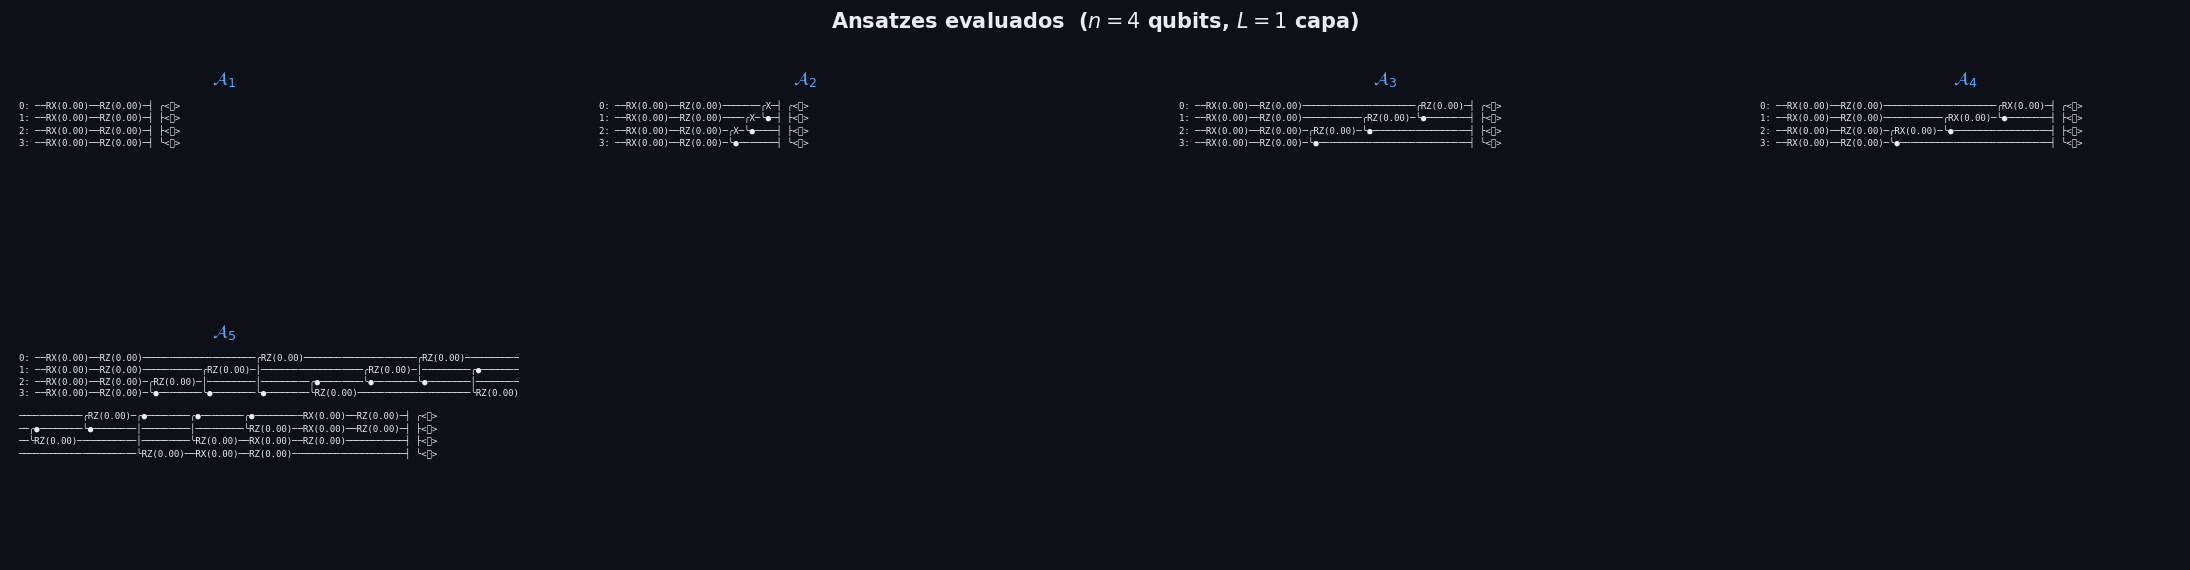

In [24]:
# Construye los QNodes en modo expval con L=1 para dibujar
A.configure(N_QUBITS, L_layers=1, output_mode="expval")
A.H = H
circuits_draw = A.get_circuits()

n_cols = 4
n_rows = int(np.ceil(len(ANSATZ_IDS) / n_cols))

fig = plt.figure(figsize=(n_cols * 5.5, n_rows * 2.8))
fig.patch.set_facecolor("#0d1117")

sample_params = pnp.zeros(A.per_layer_budget(N_QUBITS))

for k, aid in enumerate(ANSATZ_IDS):
    ax = fig.add_subplot(n_rows, n_cols, k + 1)
    ax.set_facecolor("#0d1117")

    circ = circuits_draw[aid - 1]
    # Dibuja el circuito como texto usando qml.draw
    drawer = qml.draw(circ, show_all_wires=True)
    circuit_str = drawer(sample_params)

    ax.text(
        0.02, 0.95, circuit_str,
        transform=ax.transAxes,
        fontsize=6.5, fontfamily="monospace",
        verticalalignment="top",
        color="#e6edf3",
        wrap=False,
    )
    ax.set_title(
        rf"$\mathcal{{A}}_{{{aid}}}$",
        fontsize=13, color="#58a6ff",
        pad=4,
        fontweight="bold",
    )
    ax.axis("off")

    # borde sutil
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
        spine.set_linewidth(0.8)
        spine.set_visible(True)

# ocultar ejes sobrantes
total_subplots = n_rows * n_cols
for k in range(len(ANSATZ_IDS), total_subplots):
    ax = fig.add_subplot(n_rows, n_cols, k + 1)
    ax.set_facecolor("#0d1117")
    ax.axis("off")

fig.suptitle(
    rf"Ansatzes evaluados  ($n={N_QUBITS}$ qubits, $L=1$ capa)",
    fontsize=15, color="#e6edf3", y=1.01, fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## 4 · Expresividad

Para cada par (ansatz, L), se samplea `N_PAIRS_EXPR` pares de parámetros aleatorios, se calculan los estados y sus fidelidades, y se compara la distribución empírica con la distribución de Haar mediante la divergencia KL.

In [25]:
# ── utilidades de expresividad ───────────────────────────────────────────────

def haar_bin_masses(n_qubits: int, bin_edges: np.ndarray) -> np.ndarray:
    """Masa de probabilidad por bin bajo distribución de Haar.
    P(F) = (N-1)(1-F)^{N-2}, N=2^n.
    Integral analítica por tramos: ∫_a^b P dF = (1-a)^{N-1} - (1-b)^{N-1}.
    """
    N = 2 ** n_qubits
    masses = np.array(
        [(1 - a) ** (N - 1) - (1 - b) ** (N - 1)
         for a, b in zip(bin_edges[:-1], bin_edges[1:])],
        dtype=float,
    )
    masses = np.clip(masses, 0.0, 1.0)
    return masses / masses.sum()


def kl_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, None);  p /= p.sum()
    q = np.clip(q, eps, None);  q /= q.sum()
    return float(np.sum(p * np.log(p / q)))


def compute_expressibility(
    circ, n_qubits: int, L_layers: int, n_pairs: int, n_bins: int
) -> float:
    """Devuelve D_KL(empírica || Haar) para un QNode que retorna qml.state()."""
    max_params = L_layers * A.per_layer_budget(n_qubits)
    bin_edges  = np.linspace(0.0, 1.0, n_bins + 1)
    fidelities = np.empty(n_pairs)

    for i in range(n_pairs):
        theta = rng.uniform(0.0, 2 * np.pi, size=max_params)
        phi   = rng.uniform(0.0, 2 * np.pi, size=max_params)
        psi   = np.array(circ(theta))
        varph = np.array(circ(phi))
        fidelities[i] = float(abs(np.vdot(psi, varph)) ** 2)

    counts, _ = np.histogram(fidelities, bins=bin_edges, density=False)
    p_emp  = counts.astype(float) / counts.sum()
    p_haar = haar_bin_masses(n_qubits, bin_edges)
    return kl_divergence(p_emp, p_haar)

In [26]:
# ── cálculo ──────────────────────────────────────────────────────────────────
# expr_results[L][ansatz_id (0-indexed)] = D_KL
expr_results = {L: np.full(N_ANSATZES, np.nan) for L in L_LIST}

for L_layers in L_LIST:
    print(f"\n── Expresividad  L = {L_layers} ──")
    A.configure(N_QUBITS, L_layers, output_mode="state")
    circs = A.get_circuits()

    for k, aid in enumerate(ANSATZ_IDS):
        dkl = compute_expressibility(
            circs[aid - 1], N_QUBITS, L_layers, N_PAIRS_EXPR, N_BINS_EXPR
        )
        expr_results[L_layers][k] = dkl
        print(f"  Ansatz {aid:2d}: D_KL = {dkl:.4f}")

print("\n✓ Expresividad calculada.")


── Expresividad  L = 1 ──
  Ansatz  1: D_KL = 0.3747
  Ansatz  2: D_KL = 0.3198
  Ansatz  3: D_KL = 0.2826
  Ansatz  4: D_KL = 0.1981
  Ansatz  5: D_KL = 0.1453

✓ Expresividad calculada.


In [27]:
# ── tabla de resultados ───────────────────────────────────────────────────────
expr_df = pd.DataFrame(
    {f"L={L}": expr_results[L] for L in L_LIST},
    index=[f"A{aid}" for aid in ANSATZ_IDS],
)
expr_df.index.name = "Ansatz"

print("\nTabla de Expresividad  D_KL(empírica ‖ Haar)")
print("(valores menores = más parecido a Haar = más expresivo)\n")
display(expr_df.style
    .format("{:.4f}")
    .background_gradient(cmap="YlOrRd", axis=None)
    .set_caption("Expresividad: D_KL por ansatz y número de capas")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px")]
    }])
)


Tabla de Expresividad  D_KL(empírica ‖ Haar)
(valores menores = más parecido a Haar = más expresivo)



,L=1
Ansatz,
A1,0.3747
A2,0.3198
A3,0.2826
A4,0.1981
A5,0.1453


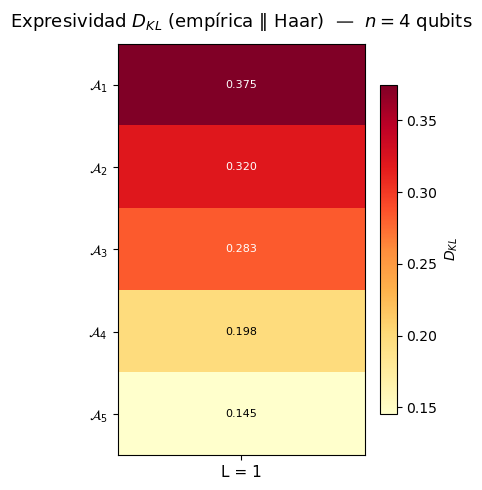

In [28]:
# ── heatmap visual ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(4, len(L_LIST) * 1.6), max(5, N_ANSATZES * 0.45)))

data = expr_df.values
im   = ax.imshow(data, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(L_LIST)))
ax.set_xticklabels([f"L = {L}" for L in L_LIST], fontsize=11)
ax.set_yticks(range(N_ANSATZES))
ax.set_yticklabels([rf"$\mathcal{{A}}_{{{aid}}}$" for aid in ANSATZ_IDS], fontsize=10)
ax.set_title(
    rf"Expresividad $D_{{KL}}$ (empírica $\|$ Haar)  —  $n={N_QUBITS}$ qubits",
    fontsize=13, pad=12
)

# anotaciones con el valor
for i in range(N_ANSATZES):
    for j in range(len(L_LIST)):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color="black" if val < data.max() * 0.6 else "white")

plt.colorbar(im, ax=ax, label=r"$D_{KL}$", shrink=0.8)
plt.tight_layout()
plt.show()

---
## 5 · Entrenabilidad

Métrica de Holmes: para cada ansatz y número de capas se samplea `N_REPEATS_TRAIN` configuraciones de parámetros aleatorios, se calculan los gradientes respecto al Hamiltoniano `H`, y se promedia la varianza por parámetro activo (aquellos cuyo gradiente no es identicamente 0).

In [29]:
# ── cálculo ──────────────────────────────────────────────────────────────────
# train_results[L][ansatz_id (0-indexed)] = Holmes metric
train_results = {L: np.full(N_ANSATZES, np.nan) for L in L_LIST}

GRAD_TOL = 1e-10   # umbral para considerar un parámetro "activo"

for L_layers in L_LIST:
    print(f"\n── Entrenabilidad  L = {L_layers} ──")
    A.configure(N_QUBITS, L_layers, output_mode="expval")
    A.H = H
    circs = A.get_circuits()
    n_params = L_layers * A.per_layer_budget(N_QUBITS)

    for k, aid in enumerate(ANSATZ_IDS):
        circ     = circs[aid - 1]
        grad_fn  = qml.grad(circ)
        grads    = np.zeros((N_REPEATS_TRAIN, n_params))

        for rep in range(N_REPEATS_TRAIN):
            params      = pnp.array(
                rng.uniform(-np.pi, np.pi, size=n_params), requires_grad=True
            )
            grads[rep]  = np.array(grad_fn(params), dtype=float)

        # parámetros activos: alguna vez gradiente distinto de 0
        active = ~np.all(np.isclose(grads, 0.0, atol=GRAD_TOL), axis=0)

        if not active.any():
            metric = 0.0
        else:
            # Var[g_p] ≈ E[g_p²]  (asumiendo E[g_p]≈0 por simetría)
            metric = float((grads[:, active] ** 2).mean())

        train_results[L_layers][k] = metric
        print(f"  Ansatz {aid:2d}: Holmes = {metric:.4e}")

print("\n✓ Entrenabilidad calculada.")


── Entrenabilidad  L = 1 ──
  Ansatz  1: Holmes = 2.4984e-01
  Ansatz  2: Holmes = 1.6930e-01
  Ansatz  3: Holmes = 1.7998e-01
  Ansatz  4: Holmes = 1.5999e-01
  Ansatz  5: Holmes = 1.2615e-01

✓ Entrenabilidad calculada.


In [19]:
# ── tabla de resultados ───────────────────────────────────────────────────────
train_df = pd.DataFrame(
    {f"L={L}": train_results[L] for L in L_LIST},
    index=[f"A{aid}" for aid in ANSATZ_IDS],
)
train_df.index.name = "Ansatz"

print("\nTabla de Entrenabilidad  (Holmes metric: media de Var[∂E/∂θ] sobre parámetros activos)")
print("(valores mayores = gradientes más grandes = más entrenable)\n")
display(train_df.style
    .format("{:.2e}")
    .background_gradient(cmap="Blues", axis=None)
    .set_caption("Entrenabilidad: Holmes metric por ansatz y número de capas")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px")]
    }])
)


Tabla de Entrenabilidad  (Holmes metric: media de Var[∂E/∂θ] sobre parámetros activos)
(valores mayores = gradientes más grandes = más entrenable)



,L=1,L=2,L=3
Ansatz,,,
A1,2.50e-01,2.51e-01,2.42e-01


---
## 6 · Resumen comparativo

Scatter plot expresividad vs entrenabilidad para todas las combinaciones (ansatz, L).

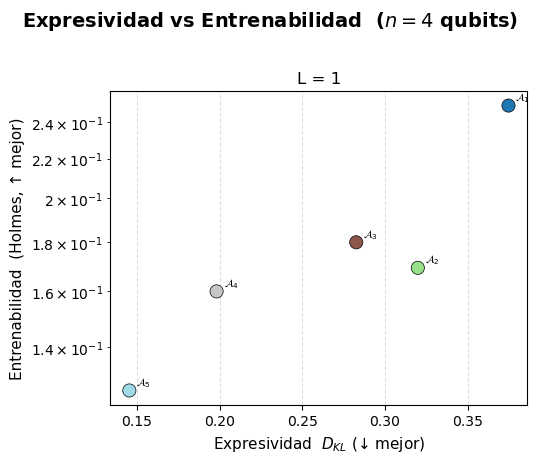

In [31]:
fig, axes = plt.subplots(1, len(L_LIST), figsize=(5.5 * len(L_LIST), 4.5), sharey=False)

if len(L_LIST) == 1:
    axes = [axes]

for ax, L_layers in zip(axes, L_LIST):
    expr_vals  = expr_results[L_layers]
    train_vals = train_results[L_layers]

    sc = ax.scatter(
        expr_vals, train_vals,
        c=ANSATZ_IDS, cmap="tab20",
        s=90, zorder=3, edgecolors="black", linewidths=0.5
    )
    for i, aid in enumerate(ANSATZ_IDS):
        ax.annotate(
            rf"$\mathcal{{A}}_{{{aid}}}$",
            (expr_vals[i], train_vals[i]),
            textcoords="offset points", xytext=(5, 4),
            fontsize=7.5
        )

    ax.set_xlabel(r"Expresividad  $D_{KL}$ (↓ mejor)", fontsize=11)
    ax.set_ylabel(r"Entrenabilidad  (Holmes, ↑ mejor)", fontsize=11)
    ax.set_title(f"L = {L_layers}", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_yscale("log")

fig.suptitle(
    rf"Expresividad vs Entrenabilidad  ($n={N_QUBITS}$ qubits)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()